# STATS EXAM  <hr style="border:2.5px solid #e625ff"></hr>

<b>Gellor, Ma. Dolores G.</b>
<br>Computer Engineering Technology

In [1]:
# imports and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestPower

In [2]:
#loading datsets
df = pd.read_csv(r'foodDiet.csv',delimiter=",")

df

FileNotFoundError: [Errno 2] No such file or directory: 'foodDiet.csv'

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Person        78 non-null     int64  
 1   gender        78 non-null     int64  
 2   Age           78 non-null     int64  
 3   Height        78 non-null     int64  
 4   pre.weight    78 non-null     int64  
 5   Diet          78 non-null     int64  
 6   weight6weeks  78 non-null     float64
dtypes: float64(1), int64(6)
memory usage: 4.4 KB


In [ ]:
df.describe()

,Person,gender,Age,Height,pre.weight,Diet,weight6weeks
count,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000
mean,39.500000,0.423077,39.153846,170.820513,72.525641,2.038462,68.680769
std,22.660538,0.497245,9.815277,11.276621,8.723344,0.812920,8.924504
min,1.000000,0.000000,16.000000,141.000000,58.000000,1.000000,53.000000
25%,20.250000,0.000000,32.250000,164.250000,66.000000,1.000000,61.850000
50%,39.500000,0.000000,39.000000,169.500000,72.000000,2.000000,68.950000
75%,58.750000,1.000000,46.750000,174.750000,78.000000,3.000000,73.825000
max,78.000000,1.000000,60.000000,201.000000,103.000000,3.000000,103.000000


## Data Cleaning <hr style="border:2.5px solid #e625ff"></hr>

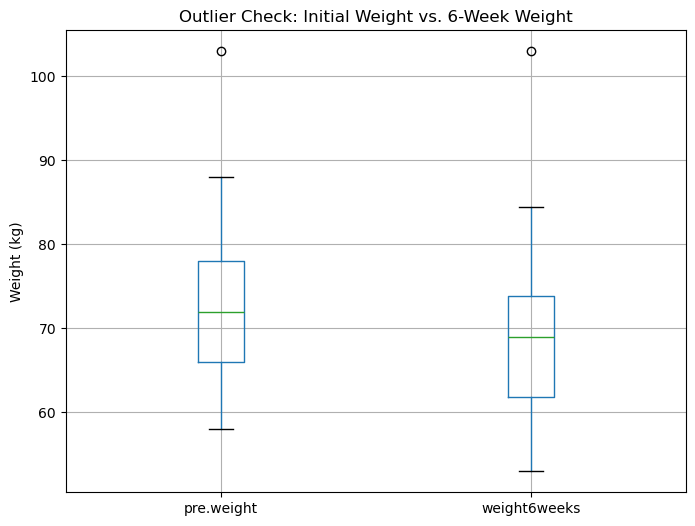

In [ ]:
# check for outliers
plt.figure(figsize=(8, 6))
df[['pre.weight', 'weight6weeks']].boxplot()

plt.title('Outlier Check: Initial Weight vs. 6-Week Weight')
plt.ylabel('Weight (kg)')
plt.show()

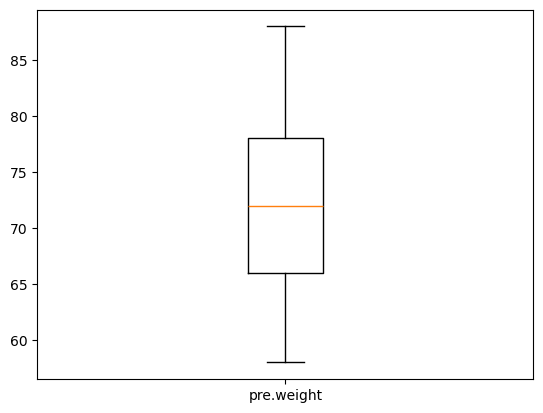

In [ ]:
# Pre.weight outliers
# removing 3-sigma outliers
z_wind = stats.zscore(df['pre.weight'])
wind_outliers = (z_wind<-3)|(z_wind>3)
df = df[~wind_outliers]

plt.boxplot(df['pre.weight'],tick_labels=['pre.weight'])
plt.show()

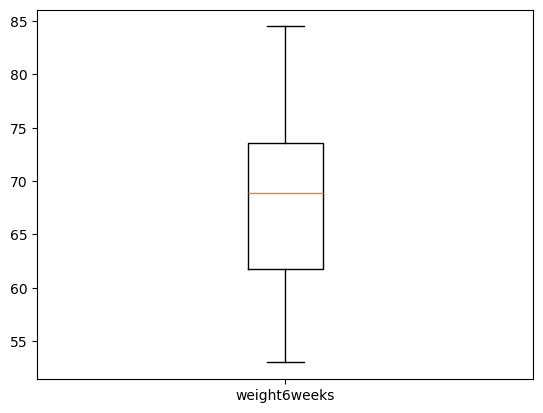

In [ ]:
# Weight6weeks outliers
# removing 3-sigma outliers
z_wind = stats.zscore(df['weight6weeks'])
wind_outliers = (z_wind<-3)|(z_wind>3)
df = df[~wind_outliers]

plt.boxplot(df['weight6weeks'],tick_labels=['weight6weeks'])
plt.show()

In [ ]:
#storage of means
means_data = {col: [] for col in df.columns}

In [ ]:
np.random.seed(42)
target_cols = ['pre.weight', 'weight6weeks']
means_data = {c: [] for c in target_cols} # Only target columns

for _ in range(50):
    for c in target_cols:
        sample = np.random.choice(df[c], size=30, replace=True)
        means_data[c].append(np.mean(sample))

In [ ]:
df_means = pd.DataFrame(means_data)
df_means

,pre.weight,weight6weeks
0,73.800000,68.086667
1,74.333333,67.293333
2,73.366667,67.533333
3,70.633333,65.516667
4,70.633333,68.150000
5,69.000000,72.346667
6,69.500000,67.606667
7,72.566667,67.296667
8,72.100000,67.690000
9,71.000000,69.910000


In [ ]:
df_means.to_csv('FoodDiet-sample.csv', index=False)


In [ ]:
df = pd.read_csv('FoodDiet-sample.csv', delimiter=",")
df.head()

,pre.weight,weight6weeks
0,73.800000,68.086667
1,74.333333,67.293333
2,73.366667,67.533333
3,70.633333,65.516667
4,70.633333,68.150000


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   pre.weight    50 non-null     float64
 1   weight6weeks  50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


In [ ]:
df.describe()

,pre.weight,weight6weeks
count,50.000000,50.000000
mean,71.909333,67.951067
std,1.590306,1.644703
min,67.400000,64.446667
25%,71.025000,67.248333
50%,72.083333,67.775000
75%,73.158333,69.159167
max,74.333333,72.346667


## Normality Test <hr style="border:2.5px solid #e625ff"></hr>

In [ ]:
# shapiro-wilk normality test
print("Pre-weight:")
w_stat, p_value = stats.shapiro(df['pre.weight'])

print(f"w_stat: {w_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")
    
print("\nWeight6weeks:")
w_stat, p_value = stats.shapiro(df['weight6weeks'])

print(f"w_stat: {w_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")

Pre-weight:
w_stat: 0.9584
P-value: 0.0763
Normal data

Weight6weeks:
w_stat: 0.9783
P-value: 0.4838
Normal data


## Paired T-test <hr style="border:2.5px solid #e625ff"></hr>

In [ ]:
df = pd.read_csv('FoodDiet-sample.csv', delimiter=",")
df

,pre.weight,weight6weeks
0,73.800000,68.086667
1,74.333333,67.293333
2,73.366667,67.533333
3,70.633333,65.516667
4,70.633333,68.150000
5,69.000000,72.346667
6,69.500000,67.606667
7,72.566667,67.296667
8,72.100000,67.690000
9,71.000000,69.910000


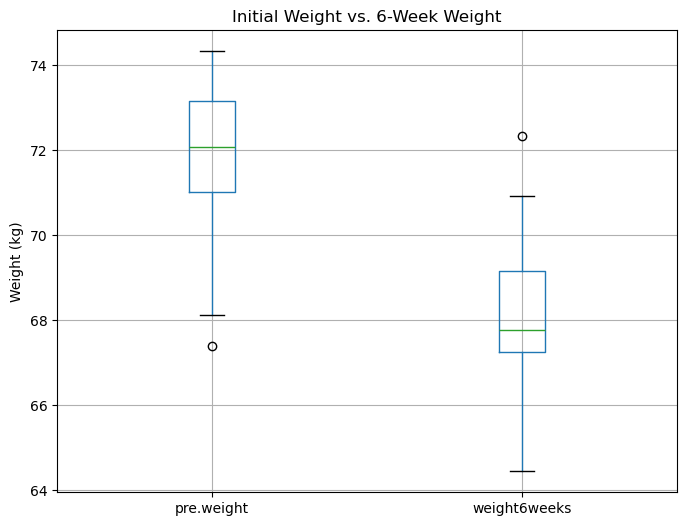

In [ ]:
# check for outliers
plt.figure(figsize=(8, 6))
df[['pre.weight', 'weight6weeks']].boxplot()

plt.title('Initial Weight vs. 6-Week Weight')
plt.ylabel('Weight (kg)')
plt.show()

In [ ]:
"""
F-Test for equality of variances
--------------------------------
Ho: var_before = var_after
Ha: var_before != var_after
"""

var_before = df['pre.weight'].var(ddof=1)
var_after = df['weight6weeks'].var(ddof=1)

# F-statistic
if var_before > var_after:
    f_stat = var_after/var_before
else:
    f_stat = var_before/var_after

print(f'F-statistic = {f_stat:.4f}')

# Degrees of Freedom
dof_before = df['pre.weight'].count()-1
dof_after = df['weight6weeks'].count()-1

# probability value
p_value = 1 - stats.f.cdf(f_stat, dof_before, dof_after)
print(f'p-value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("unequal variances")
else:
    # fail to reject null hypothesis
    print("equal variances")

F-statistic = 0.9349
p-value = 0.5926
equal variances


In [ ]:
"""
Paired T-Test (Nuclear Maintenance)
"""
t_stat, p_value = stats.ttest_rel(df['pre.weight'],df['weight6weeks'])
print(f't_stat = {t_stat:.4f}')
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("There is a significant improvement after the Diet.")
    # fail to reject null hypothesis
else:
    print("There is no significant difference before and after the Diet.")

t_stat = 12.0923
p_value = 0.0000
There is a significant improvement after the Diet.
